In [2]:
import os
# Force TensorFlow to use CPU only
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
# Verify it's using CPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# Should print 0

Num GPUs Available:  0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
# import simple imputer
from sklearn.impute import SimpleImputer
#import label
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
CLINICAL_DIR = 'clinical'
GENOMIC_DIR = 'genomic'
OUTPUT_DIR = 'output'

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
def load_cbioportal_file(filepath):
    """
    Reads cBioPortal text files, skipping header lines starting with '#'
    """
    try:
        # cBioPortal files often have 4-5 header lines starting with '#'
        # We read the file to find where the data starts
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        header_row = 0
        for i, line in enumerate(lines):
            if not line.startswith('#'):
                header_row = i
                break
        
        # Load data
        df = pd.read_csv(filepath, sep='\t', header=header_row)
        print(f"Loaded {os.path.basename(filepath)}: {df.shape}")
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

In [6]:
print("Loading Clinical Files...")

# A. Patient Data (Demographics + Survival)
# Priority: PanCan Atlas (cleaner survival data)
df_patient = load_cbioportal_file(os.path.join(CLINICAL_DIR, 'data_clinical_patient.txt'))
df_patient_gdc = load_cbioportal_file(os.path.join(CLINICAL_DIR, 'data_clinical_patient_gdc.txt'))

# B. Sample Data (Tumor Stage, Type)
df_sample = load_cbioportal_file(os.path.join(CLINICAL_DIR, 'data_clinical_sample.txt'))
df_hypoxia = load_cbioportal_file(os.path.join(CLINICAL_DIR, 'data_clinical_supp_hypoxia.txt'))

Loading Clinical Files...
Loaded data_clinical_patient.txt: (566, 38)
Loaded data_clinical_patient_gdc.txt: (585, 33)
Loaded data_clinical_sample.txt: (566, 19)
Loaded data_clinical_supp_hypoxia.txt: (510, 4)


In [7]:
print("\nProcessing IDs & Merging...")

# Standardize Patient ID column name
# cBioPortal usually uses 'PATIENT_ID', ensure it's consistent
df_patient.rename(columns={'PATIENT_ID': 'Patient_ID'}, inplace=True)
df_sample.rename(columns={'PATIENT_ID': 'Patient_ID'}, inplace=True)
if df_hypoxia is not None:
    df_hypoxia.rename(columns={'Patient_ID': 'Patient_ID'}, inplace=True) # Check actual column name

# Primary Merge: Patient + Sample
# We strictly use the PanCan Atlas patient file as the "Anchor" because it has the best survival data
clinical_merged = pd.merge(df_patient, df_sample, on='Patient_ID', how='inner')

# Merge Hypoxia if available (This is a high-value feature)
if df_hypoxia is not None:
    # Hypoxia file often uses 'Patient_ID' or 'Sample_ID'. Let's ensure we match on Patient_ID.
    # If the hypoxia file uses long IDs (TCGA-XX-XXXX-01), we truncate them.
    if 'Patient_ID' in df_hypoxia.columns:
         clinical_merged = pd.merge(clinical_merged, df_hypoxia[['Patient_ID', 'Buffa_hypoxia_score', 'Ragnum_hypoxia_score']], 
                                    on='Patient_ID', how='left')
    elif 'Sample_ID' in df_hypoxia.columns:
        # Create a temp Patient_ID from Sample_ID
        df_hypoxia['Patient_ID'] = df_hypoxia['Sample_ID'].apply(lambda x: '-'.join(x.split('-')[:3]))
        clinical_merged = pd.merge(clinical_merged, df_hypoxia[['Patient_ID', 'Buffa_hypoxia_score']], 
                                    on='Patient_ID', how='left')

print(f"Merged Clinical Data Shape: {clinical_merged.shape}")


Processing IDs & Merging...
Merged Clinical Data Shape: (566, 56)


In [8]:
clinical_merged

,Patient_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE
0,TCGA-05-4244,LUAD,LUAD,34040b83-7e8a-4264-a551-b16621843e28,70.0,Male,STAGE IV,6TH,0.0,-25752.0,...,5,Lung,17.0,Primary,0.2886,0.03,Matched,6.400000,Indivumed,98.0
1,TCGA-05-4249,LUAD,LUAD,4addf05f-3668-4b3f-a17f-c0227329ca52,67.0,Male,STAGE IB,6TH,1523.0,-24532.0,...,5,Lung,24.0,Primary,0.2807,0.07,Matched,10.000000,Indivumed,29.0
2,TCGA-05-4250,LUAD,LUAD,f98ecd8a-b878-4f53-b911-20cd8e17281c,79.0,Female,STAGE IIIA,6TH,NaN,-29068.0,...,5,Lung,17.0,Primary,0.3059,0.28,Matched,10.500000,Indivumed,81.0
3,TCGA-05-4382,LUAD,LUAD,3434b91a-c05f-460f-a078-7b1bb6e7085d,68.0,Male,STAGE IB,6TH,607.0,-24868.0,...,5,Lung,22.0,Primary,0.3193,0.05,Matched,51.733333,Indivumed,226.0
4,TCGA-05-4384,LUAD,LUAD,9a50e7e4-831d-489f-87d2-979e987561cc,66.0,Male,STAGE IIIA,6TH,426.0,-24411.0,...,5,Lung,1.0,Primary,0.2850,0.00,Matched,3.966667,Indivumed,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
561,TCGA-17-Z045,NaN,LUAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17,NaN,NaN,Primary,0.3020,0.00,Matched,20.200000,Washington University,NaN
562,TCGA-17-Z031,NaN,LUAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17,NaN,NaN,Primary,0.3022,0.55,Matched,69.533333,Washington University,NaN
563,TCGA-17-Z049,NaN,LUAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17,NaN,NaN,Primary,0.2793,0.19,Matched,16.433333,Washington University,NaN
564,TCGA-17-Z060,NaN,LUAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17,NaN,NaN,Primary,0.2807,0.05,Matched,7.266667,Washington University,NaN


In [9]:
print("\nCreating Target Variable...")

# We need a target for classification.
# Options: 
# 1. 'OS_STATUS' (Living:0 vs Deceased:1)
# 2. 'OS_MONTHS' (Regression)
# 3. 'High_Risk' (Deceased within < 24 months vs Survived > 24 months)

# Let's clean the Status column
# Usually encoded as '0:LIVING', '1:DECEASED'
clinical_merged['OS_STATUS'] = clinical_merged['OS_STATUS'].astype(str).apply(lambda x: 1 if 'DECEASED' in x.upper() or '1' in x else 0)

# Clean Survival Months
clinical_merged['OS_MONTHS'] = pd.to_numeric(clinical_merged['OS_MONTHS'], errors='coerce')

# CREATE TARGET: "High Risk" Classification
# Logic: If patient died within 24 months -> High Risk (1). Else -> Low Risk (0).
# (Note: Living patients with < 24 months follow-up are ambiguous/censored. We will drop them for training clarity.)

def define_risk(row):
    cutoff = 12.0 # 1 Year
    if row['OS_STATUS'] == 1 and row['OS_MONTHS'] < cutoff:
        return 1 # Died early (High Risk)
    elif row['OS_MONTHS'] >= cutoff:
        return 0 # Survived past 2 years (Low Risk)
    else:
        return np.nan # Censored/Unknown (Living but observed for < 24 months)

clinical_merged['Target_Risk'] = clinical_merged.apply(define_risk, axis=1)

# Drop rows where target is unknown (approx 10-15% of data usually)
clinical_cleaned = clinical_merged.dropna(subset=['Target_Risk'])
print(f"Data remaining after dropping censored patients: {clinical_cleaned.shape}")


Creating Target Variable...
Data remaining after dropping censored patients: (452, 57)


In [10]:
clinical_cleaned.columns

Index(['Patient_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID',
       'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION',
       'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH',
       'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY',
       'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10',
       'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED',
       'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE',
       'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS',
       'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE',
       'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS',
       'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS',
       'PFS_STATUS', 'PFS_MONTHS', 'GENETIC_ANCESTRY_LABEL', 'SAMPLE_ID',
       'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'TUMOR_TYPE',
       'GRADE', 'TISSUE_PROSPECTIVE_COLLECTION_INDICATOR',
       'TISSUE_RETROSPEC

In [13]:
print("\nSelecting Features...")

keep_cols = [
'Patient_ID', 
    'AGE', 
    'SEX', 
    'RACE', 
    'AJCC_PATHOLOGIC_TUMOR_STAGE',  # Overall Stage (I, II, III, IV)
    'PATH_T_STAGE',                 # Tumor Size
    'PATH_N_STAGE',                 # Lymph Node involvement
    'PATH_M_STAGE',                 # Metastasis
    'TMB_NONSYNONYMOUS',            # Tumor Mutational Burden (Molecular Feature)
    'ANEUPLOIDY_SCORE',             # Chromosomal Instability (Molecular Feature)
    'MSI_SENSOR_SCORE',             # Microsatellite Instability (Molecular Feature)
    'Target_Risk'                         
]

# Intersect with available columns
available_cols = [c for c in keep_cols if c in clinical_cleaned.columns]
df_final = clinical_cleaned[available_cols].copy()
df_final


Selecting Features...


,Patient_ID,AGE,SEX,RACE,AJCC_PATHOLOGIC_TUMOR_STAGE,PATH_T_STAGE,PATH_N_STAGE,PATH_M_STAGE,TMB_NONSYNONYMOUS,ANEUPLOIDY_SCORE,MSI_SENSOR_SCORE,Target_Risk
1,TCGA-05-4249,67.0,Male,NaN,STAGE IB,T2,N0,M0,10.000000,24.0,0.07,0.0
2,TCGA-05-4250,79.0,Female,NaN,STAGE IIIA,T3,N1,M0,10.500000,17.0,0.28,1.0
3,TCGA-05-4382,68.0,Male,NaN,STAGE IB,T2,N0,M0,51.733333,22.0,0.05,0.0
4,TCGA-05-4384,66.0,Male,NaN,STAGE IIIA,T2,N2,M0,3.966667,1.0,0.00,0.0
5,TCGA-05-4389,70.0,Male,NaN,STAGE IA,T1,N0,M0,7.033333,20.0,0.05,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
507,TCGA-NJ-A4YQ,69.0,Female,White,STAGE IA,T1B,N0,M0,33.466667,15.0,0.01,0.0
510,TCGA-NJ-A55R,67.0,Male,White,STAGE IA,T1B,N0,MX,7.700000,21.0,0.00,0.0
511,TCGA-NJ-A7XG,49.0,Male,Black or African American,STAGE IIIA,T4,N1,M0,0.900000,16.0,0.00,0.0
512,TCGA-O1-A52J,74.0,Female,White,STAGE IA,T1,N0,MX,5.100000,29.0,0.02,0.0


In [14]:
# A. CLEAN NUMERICAL COLUMNS
# TMB and Aneuploidy scores are continuous. We fill missing with Median.
num_cols = ['AGE', 'TMB_NONSYNONYMOUS', 'ANEUPLOIDY_SCORE', 'MSI_SENSOR_SCORE']
imputer = SimpleImputer(strategy='median')
df_final[num_cols] = imputer.fit_transform(df_final[num_cols])

In [15]:
# B. CLEAN CATEGORICAL COLUMNS
# Stages often have sub-classifications like 'Stage IA', 'Stage IB'. 
# For a baseline model, grouping them helps (e.g., map 'Stage IA' -> 'Stage I').
# However, XGBoost handles cardinality well, so we will just clean missing values first.

cat_cols = ['SEX', 'RACE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'PATH_T_STAGE', 'PATH_N_STAGE', 'PATH_M_STAGE']

In [16]:
# Fill categorical NaNs with "Unknown"
df_final[cat_cols] = df_final[cat_cols].fillna('Unknown')

In [17]:
print("Encoding Categorical Variables...")

# We use Label Encoding for the columns. 
# (Note: For the later Deep Learning Multimodal model, we will likely switch to One-Hot, 
# but for this Gradient Boosting baseline, Label Encoding is efficient).

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Convert to string to handle mixed types, then encode
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    label_encoders[col] = le

print(f"Final Data Shape for Training: {df_final.shape}")
print(df_final.head())

Encoding Categorical Variables...
Final Data Shape for Training: (452, 12)
     Patient_ID   AGE  SEX  RACE  AJCC_PATHOLOGIC_TUMOR_STAGE  PATH_T_STAGE  \
1  TCGA-05-4249  67.0    1     3                            2             3   
2  TCGA-05-4250  79.0    0     3                            6             6   
3  TCGA-05-4382  68.0    1     3                            2             3   
4  TCGA-05-4384  66.0    1     3                            6             3   
5  TCGA-05-4389  70.0    1     3                            1             0   

   PATH_N_STAGE  PATH_M_STAGE  TMB_NONSYNONYMOUS  ANEUPLOIDY_SCORE  \
1             0             0          10.000000              24.0   
2             1             0          10.500000              17.0   
3             0             0          51.733333              22.0   
4             2             0           3.966667               1.0   
5             0             0           7.033333              20.0   

   MSI_SENSOR_SCORE  Target_R

In [18]:
# 1. Separate Features and Target
# We drop 'Patient_ID' because it is an identifier, not a predictive feature
X = df_final.drop(columns=['Target_Risk', 'Patient_ID'])
y = df_final['Target_Risk']

# 2. Split into Train (80%) and Test (20%)
# Stratify ensures the proportion of 0s and 1s remains the same in train and test splits initially
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the Data (Standardization)
# CRITICAL: Fit the scaler ONLY on X_train to prevent data leakage, then transform X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Training shape: (361, 10)
Testing shape: (91, 10)


Original class distribution in Training set:
Target_Risk
0.0    315
1.0     46
Name: count, dtype: int64

Class distribution after SMOTE:
Target_Risk
1.0    315
0.0    315
Name: count, dtype: int64


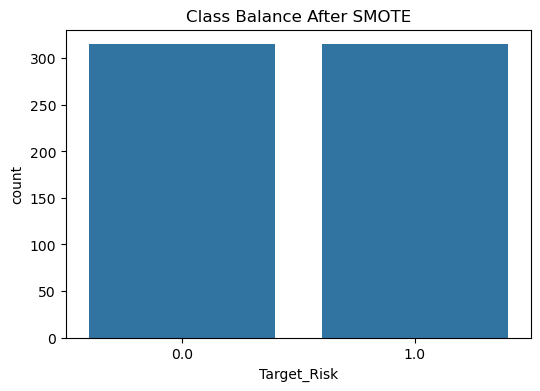

In [19]:
print("Original class distribution in Training set:")
print(y_train.value_counts())

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

# Visualization check
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled)
plt.title("Class Balance After SMOTE")
plt.show()

In [20]:
# def build_clinical_model(input_dim):
#     model = Sequential()
    
#     # Input Layer + First Hidden Layer
#     # L2 Regularization or Dropout helps when data count is low relative to complexity
#     model.add(Dense(64, input_dim=input_dim, activation='relu'))
#     model.add(BatchNormalization()) # Helps training stability
#     model.add(Dropout(0.3))         # Prevents overfitting
    
#     # Second Hidden Layer
#     model.add(Dense(32, activation='relu'))
#     model.add(BatchNormalization())
#     model.add(Dropout(0.2))
    
#     # Output Layer
#     # Sigmoid activation because this is binary classification (0 or 1)
#     model.add(Dense(1, activation='sigmoid'))
    
#     # Compile
#     model.compile(optimizer=Adam(learning_rate=0.001),
#                   loss='binary_crossentropy',
#                   metrics=['accuracy'])
    
#     return model

# # Initialize model
# input_dim = X_train_resampled.shape[1]
# clinical_model = build_clinical_model(input_dim)

# print(clinical_model.summary())

In [21]:
from sklearn.utils import class_weight
from tensorflow.keras.regularizers import l2

# 1. Calculate Class Weights (Instead of SMOTE)
# This tells the model: "If you get a High Risk patient wrong, it costs you way more error."
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class Weights Calculated: {class_weight_dict}")

# 2. Simplified Model Architecture
def build_simple_clinical_model(input_dim):
    model = Sequential()
    
    # Reduced neurons (32 instead of 64) and added L2 regularization
    model.add(Dense(32, input_dim=input_dim, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4)) # Higher dropout to ignore noise
    
    # Second layer reduced to 16
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))
    
    model.add(Dense(1, activation='sigmoid'))
    
    # Lower learning rate for more stable convergence
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 3. Train on ORIGINAL Scaled Data (Not Resampled)
# We use X_train_scaled, NOT X_train_resampled
input_dim = X_train_resampled.shape[1]
clinical_model_v2 = build_simple_clinical_model(input_dim)

checkpoint_path_v2 = 'output/best_clinical_model_v2.h5'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path_v2, monitor='val_loss', save_best_only=True, mode='min', verbose=1)
]

print("\nStarting Training with Class Weights...")
history = clinical_model_v2.fit(
    X_train_scaled, y_train,  # Original data
    validation_data=(X_test_scaled, y_test),
    epochs=300,
    batch_size=16, # Smaller batch size for better updates on small data
    class_weight=class_weight_dict, # APPLY WEIGHTS HERE
    callbacks=callbacks,
    verbose=1
)

# 4. Evaluate
print("\n--- Improved Clinical Model Evaluation ---")
y_pred_prob = clinical_model_v2.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Save this scaler as the final one if results are better
if accuracy_score(y_test, y_pred) > 0.6: 
    joblib.dump(scaler, 'output/clinical_scaler.pkl')
    print("Scaler updated.")

Class Weights Calculated: {0: np.float64(0.573015873015873), 1: np.float64(3.9239130434782608)}


/opt/anaconda3/envs/main_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Training with Class Weights...
Epoch 1/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6250 - loss: 0.8415
Epoch 1: val_loss improved from None to 1.08882, saving model to output/best_clinical_model_v2.h5

Epoch 1: val_loss improved from None to 1.08882, saving model to output/best_clinical_model_v2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4737 - loss: 1.2110 - val_accuracy: 0.4396 - val_loss: 1.0888
Epoch 2/300
Epoch 2/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3125 - loss: 1.6791
Epoch 2: val_loss improved from 1.08882 to 1.07036, saving model to output/best_clinical_model_v2.h5

Epoch 2: val_loss improved from 1.08882 to 1.07036, saving model to output/best_clinical_model_v2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4349 - loss: 1.2648 - val_accuracy: 0.4505 - val_loss: 1.0704
Epoch 3/300
Epoch 3/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3125 - loss: 1.2055
Epoch 3: val_loss improved from 1.07036 to 1.05978, saving model to output/best_clinical_model_v2.h5

Epoch 3: val_loss improved from 1.07036 to 1.05978, saving model to output/best_clinical_model_v2.h5


...

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7673 - loss: 0.5841 - val_accuracy: 0.7253 - val_loss: 0.6913
Epoch 164/300
Epoch 164/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7500 - loss: 0.3724
Epoch 164: val_loss did not improve from 0.69133
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7500 - loss: 0.3724
Epoch 164: val_loss did not improve from 0.69133
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7424 - loss: 0.6221 - val_accuracy: 0.7253 - val_loss: 0.6974
Epoch 165/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7424 - loss: 0.6221 - val_accuracy: 0.7253 - val_loss: 0.6974
Epoch 165/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6875 - loss: 0.5119
Epoch 165: val_loss did not improve from 0.69133
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7341 - loss: 0.6319 - val_accuracy: 0.7253 - val_loss: 0.7022
Epoch 166/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 0.6343
Epoch 165: val_loss did not

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7645 - loss: 0.5571 - val_accuracy: 0.7253 - val_loss: 0.6905
Epoch 177/300
Epoch 177/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8125 - loss: 0.3945
Epoch 177: val_loss improved from 0.69045 to 0.68995, saving model to output/best_clinical_model_v2.h5

Epoch 177: val_loss improved from 0.69045 to 0.68995, saving model to output/best_clinical_model_v2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7091 - loss: 0.6329 - val_accuracy: 0.7143 - val_loss: 0.6900
Epoch 178/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.4587
Epoch 178: val_loss improved from 0.68995 to 0.68320, saving model to output/best_clinical_model_v2.h5
Epoch 178/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.4587
Epoch 178: val_loss improved from 0.68995 to 0.68320, saving model to output/best_clinical_model_v2.h5


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7230 - loss: 0.5971 - val_accuracy: 0.7143 - val_loss: 0.6832
Epoch 179/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8125 - loss: 0.7921Epoch 179/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8125 - loss: 0.7921
Epoch 179: val_loss did not improve from 0.68320
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7507 - loss: 0.5555 - val_accuracy: 0.7143 - val_loss: 0.6878
Epoch 180/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8750 - loss: 0.4502
Epoch 179: val_loss did not improve from 0.68320
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7507 - loss: 0.5555 - val_accuracy: 0.7143 - val_loss: 0.6878
Epoch 180/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8750 - loss: 0.4502
Epoch 180: val_loss did not improve from 0.68320
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7812 - loss: 0.5763 - val_accuracy: 0.7143 - val_loss: 0.6896
Epoch 181/300
 1/23 ━━━━━━━━━━━━━━━━━━━━ 

NameError: name 'joblib' is not defined

In [22]:
# SHAP & LIME: safe import / install fallback
try:
    import shap
    from lime import lime_tabular
    import joblib
except Exception as e:
    import sys, subprocess
    print('Some packages missing, installing: shap, lime, joblib')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', 'lime', 'joblib'])
    import shap
    from lime import lime_tabular
    import joblib
import numpy as np
import matplotlib.pyplot as plt
import os
# feature names come from the dataframe `X` defined earlier in the notebook
feature_names = list(X.columns)
class_names = ['Low_Risk', 'High_Risk']
print('SHAP & LIME imports ready. Features:', len(feature_names))

SHAP & LIME imports ready. Features: 10


/opt/anaconda3/envs/main_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
# --- SHAP explainer (KernelExplainer) ---
print('Preparing SHAP KernelExplainer (this may take a little time).')
# Use kmeans background to speed up KernelExplainer
os.makedirs('output', exist_ok=True)
try:
    background = shap.kmeans(X_train_scaled, 10)
except Exception:
    # fallback: use a small random subsample as background
    idx = np.random.choice(np.arange(X_train_scaled.shape[0]), size=min(50, X_train_scaled.shape[0]), replace=False)
    background = X_train_scaled[idx]
# wrapper: model.predict returns shape (n,1) -> ravel to (n,)
model_predict = lambda x: clinical_model_v2.predict(x).ravel()
explainer_shap = shap.KernelExplainer(model_predict, background)
# Limit number of test samples explained to keep runtime reasonable
n_shap_samples = min(100, X_test_scaled.shape[0])
shap_sample_idx = np.arange(n_shap_samples)
# nsamples controls KernelExplainer accuracy / runtime; increase if you have time
print(f'Computing SHAP values for {n_shap_samples} test samples...')
shap_values = explainer_shap.shap_values(X_test_scaled[shap_sample_idx], nsamples=200)
# Save SHAP arrays (compressed)
np.savez_compressed('output/shap_values.npz', shap_values=shap_values, indices=shap_sample_idx)
# Create and save summary plot (bar or dot)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_scaled[shap_sample_idx], feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('output/shap_summary.png', dpi=150)
plt.close()
print('Saved SHAP summary: output/shap_summary.png and output/shap_values.npz')

Preparing SHAP KernelExplainer (this may take a little time).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Computing SHAP values for 91 test samples...
Computing SHAP values for 91 test samples...


  0%|          | 0/91 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step


  1%|          | 1/91 [00:00<00:24,  3.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


 99%|█████████▉| 90/91 [00:22<00:00,  4.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


100%|██████████| 91/91 [00:22<00:00,  4.07it/s]



Saved SHAP summary: output/shap_summary.png and output/shap_values.npz


In [28]:
# --- LIME explainer and helper function ---
print('Preparing LIME explainer...')
# LimeTabularExplainer expects a 2D array for training data
explainer_lime = lime_tabular.LimeTabularExplainer(training_data=X_train_scaled, feature_names=feature_names, class_names=class_names, mode='classification')
# LIME expects a predict_proba function returning shape (n_samples, n_classes)
def predict_proba_for_lime(x):
    p = clinical_model_v2.predict(x)
    # ensure shape (n,1) -> return two columns [prob_class0, prob_class1]
    p = p.reshape(-1,1)
    return np.hstack([1-p, p])
def explain_instance_with_lime(idx, num_features=10, save_html=True, save_png=True):
    # idx refers to row index in X_test_scaled (0-based for the test set)
    instance = X_test_scaled[idx]
    exp = explainer_lime.explain_instance(instance, predict_proba_for_lime, num_features=num_features)
    if save_html:
        out_file = f'output/lime_explanation_idx_{idx}.html'
        with open(out_file, 'w') as f:
            f.write(exp.as_html())
        print(f'LIME explanation saved to {out_file}')
    if save_png:
        # Create a horizontal bar chart from the LIME explanation weights and save as PNG
        try:
            items = exp.as_list()  # list of (feature, weight)
            feats = [it[0] for it in items]
            weights = [it[1] for it in items]
            import matplotlib.pyplot as _plt
            out_png = f'output/lime_explanation_idx_{idx}.png'
            _plt.figure(figsize=(8, max(2, len(feats)*0.5)))
            y_pos = list(range(len(feats)))
            colors = ['#d9534f' if w < 0 else '#5cb85c' for w in weights]
            _plt.barh(y_pos, weights, color=colors)
            _plt.yticks(y_pos, feats, fontsize=8)
            _plt.xlabel('LIME weight (positive -> increases class probability)')
            _plt.title(f'LIME explanation (test idx {idx})')
            _plt.tight_layout()
            _plt.savefig(out_png, dpi=150)
            _plt.close()
            print(f'LIME PNG saved to {out_png}')
        except Exception as e:
            print('Failed to save LIME PNG:', e)
    return exp
# Example: produce LIME for first test sample if it exists
if X_test_scaled.shape[0] > 0:
    explain_instance_with_lime(0)
print('LIME explanations available in output/')

Preparing LIME explainer...
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step
LIME explanation saved to output/lime_explanation_idx_0.html
LIME explanation saved to output/lime_explanation_idx_0.html
LIME PNG saved to output/lime_explanation_idx_0.png
LIME explanations available in output/
LIME PNG saved to output/lime_explanation_idx_0.png
LIME explanations available in output/
